In [1]:
# EUR/TL Forecast 2026-2031
# ==========================================
# Author: Osman Manay
# Date: 2026
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Modeller
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.tsa.vector_ar.var_model import VAR
    from statsmodels.regression.linear_model import OLS
    from statsmodels.tools import add_constant
    print("✅ statsmodels hazır!")
except:
    !pip install statsmodels -q
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.vector_ar.var_model import VAR

# Grafik ayarları
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style("white")

# Renkler
RED    = '#e31937'
BLUE   = '#003087'
GREEN  = '#047857'
ORANGE = '#f59e0b'
PURPLE = '#7c3aed'
GRAY   = '#666666'
GOLD   = '#b45309'

print("✅ Tüm kütüphaneler hazır!")
print("💶 EUR/TL Forecast 2026-2031 başlıyor...")

✅ statsmodels hazır!
✅ Tüm kütüphaneler hazır!
💶 EUR/TL Forecast 2026-2031 başlıyor...


In [6]:
data = {
    'year': [2010,2011,2012,2013,2014,2015,2016,2017,
             2018,2019,2020,2021,2022,2023,2024,2025],

    'eur_tl': [2.07,2.37,2.35,2.93,2.91,2.97,3.71,
               4.12,6.13,6.36,8.80,15.67,19.88,32.30,35.60,53.55],
    'usd_tl': [1.50,1.67,1.80,2.18,2.19,2.72,3.52,
               3.65,5.29,5.68,7.44,13.32,18.85,29.51,32.90,38.20],

    'cpi':    [8.57,6.47,8.89,7.40,8.17,7.67,8.53,11.92,
               20.30,15.18,14.60,19.60,72.31,64.77,44.38,30.10],
    'policy_rate': [6.50,5.75,5.50,4.50,8.25,7.50,8.00,8.00,
                    24.00,12.00,17.00,14.00,9.00,42.50,50.00,46.00],
    'gdp_growth':  [8.49,11.11,4.79,8.49,5.17,6.10,3.20,7.50,
                    3.00,-0.10,1.80,11.40,5.60,4.50,3.20,3.80],
    'current_account': [-6.40,-9.70,-6.20,-7.90,-5.50,-3.70,
                        -3.80,-5.60,-3.50,0.90,-4.90,-1.70,
                        -5.40,-4.00,-2.50,-2.00],
    'inflation_diff': [1.57,-1.53,1.89,-0.60,1.17,1.67,1.53,
                       5.92,16.30,12.18,11.60,16.60,69.31,
                       61.77,41.38,27.10],
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['year'], format='%Y')
df.set_index('date', inplace=True)
df['eur_usd'] = df['eur_tl'] / df['usd_tl']

print("=" * 60)
print("📊 EUR/TL TARİHSEL VERİ (2010-2025) — GÜNCELLENDİ")
print("=" * 60)
print(f"\n💶 EUR/TL:")
print(f"   2010    : {df['eur_tl'].iloc[0]:.2f} TRY")
print(f"   2025    : {df['eur_tl'].iloc[-1]:.2f} TRY")
print(f"   Toplam  : {((df['eur_tl'].iloc[-1]/df['eur_tl'].iloc[0])-1)*100:.1f}% değer kaybı")
print(f"   CAGR    : {((df['eur_tl'].iloc[-1]/df['eur_tl'].iloc[0])**(1/15)-1)*100:.1f}% yıllık")
print(f"\n📊 Korelasyonlar (EUR/TL ile):")
for col in ['cpi','policy_rate','gdp_growth','current_account']:
    corr = df['eur_tl'].corr(df[col])
    print(f"   EUR/TL ↔ {col:20s}: {corr:.3f}")

📊 EUR/TL TARİHSEL VERİ (2010-2025) — GÜNCELLENDİ

💶 EUR/TL:
   2010    : 2.07 TRY
   2025    : 53.55 TRY
   Toplam  : 2487.0% değer kaybı
   CAGR    : 24.2% yıllık

📊 Korelasyonlar (EUR/TL ile):
   EUR/TL ↔ cpi                 : 0.666
   EUR/TL ↔ policy_rate         : 0.893
   EUR/TL ↔ gdp_growth          : -0.228
   EUR/TL ↔ current_account     : 0.427


In [7]:
forecast_years = [2026, 2027, 2028, 2029, 2030, 2031]
n_forecast = len(forecast_years)

# ARIMA
print("=" * 60)
print("📊 MODEL 1: ARIMA")
print("=" * 60)
eur_series = df['eur_tl'].values
adf = adfuller(eur_series)
print(f"ADF p-value: {adf[1]:.4f} — {'Durağan değil' if adf[1]>0.05 else 'Durağan'}")

arima_model = ARIMA(eur_series, order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=n_forecast)
arima_conf = arima_fit.get_forecast(steps=n_forecast).conf_int()

print(f"\nARIMA(1,1,1) Tahminleri:")
for year, val, lo, hi in zip(forecast_years, arima_forecast,
                               arima_conf[:,0], arima_conf[:,1]):
    print(f"   {year}: {val:.2f} TRY  [{lo:.2f} – {hi:.2f}]")

# VAR
print("\n" + "=" * 60)
print("📊 MODEL 2: VAR")
print("=" * 60)
var_data = df[['eur_tl','cpi','policy_rate','current_account']].copy()
var_diff = var_data.diff().dropna()
var_model = VAR(var_diff)
var_fit = var_model.fit(maxlags=2, ic='aic')
print(f"VAR optimal lag: {var_fit.k_ar}")
var_forecast_diff = var_fit.forecast(var_diff.values[-var_fit.k_ar:], steps=n_forecast)
var_forecast_df = pd.DataFrame(var_forecast_diff,
                                columns=var_data.columns,
                                index=forecast_years)
last_val = var_data['eur_tl'].iloc[-1]
var_eur_forecast = []
for diff_val in var_forecast_df['eur_tl']:
    last_val = last_val + diff_val
    var_eur_forecast.append(last_val)

print(f"\nVAR Tahminleri (EUR/TL):")
for year, val in zip(forecast_years, var_eur_forecast):
    print(f"   {year}: {val:.2f} TRY")

# OLS
print("\n" + "=" * 60)
print("📊 MODEL 3: OLS Regresyon")
print("=" * 60)
from statsmodels.api import OLS, add_constant
X = df[['cpi','policy_rate','current_account','gdp_growth']]
y = df['eur_tl']
X_const = add_constant(X)
ols_fit = OLS(y, X_const).fit()
print(f"R²: {ols_fit.rsquared:.4f}")

future_macro = pd.DataFrame({
    'cpi':             [28.0,25.0,22.0,20.0,18.0,16.0],
    'policy_rate':     [40.0,35.0,30.0,28.0,25.0,22.0],
    'current_account': [-2.5,-2.8,-3.0,-3.0,-2.8,-2.5],
    'gdp_growth':      [3.5, 3.8, 4.0, 4.2, 4.0, 3.8]
}, index=forecast_years)

X_future = add_constant(future_macro, has_constant='add')
ols_forecast = ols_fit.predict(X_future)

print(f"\nOLS Tahminleri (EUR/TL):")
for year, val in zip(forecast_years, ols_forecast):
    print(f"   {year}: {val:.2f} TRY")

model_avg = [(a+v+o)/3 for a,v,o in
             zip(arima_forecast, var_eur_forecast, ols_forecast)]
print(f"\n📊 Model Ortalaması:")
for year, val in zip(forecast_years, model_avg):
    print(f"   {year}: {val:.2f} TRY")

📊 MODEL 1: ARIMA
ADF p-value: 0.9772 — Durağan değil

ARIMA(1,1,1) Tahminleri:
   2026: 64.04 TRY  [55.42 – 72.66]
   2027: 74.05 TRY  [58.99 – 89.11]
   2028: 83.60 TRY  [61.71 – 105.50]
   2029: 92.72 TRY  [63.54 – 121.90]
   2030: 101.41 TRY  [64.55 – 138.27]
   2031: 109.71 TRY  [64.83 – 154.59]

📊 MODEL 2: VAR
VAR optimal lag: 2

VAR Tahminleri (EUR/TL):
   2026: 69.20 TRY
   2027: 106.88 TRY
   2028: 130.44 TRY
   2029: 163.59 TRY
   2030: 219.52 TRY
   2031: 314.89 TRY

📊 MODEL 3: OLS Regresyon
R²: 0.8526

OLS Tahminleri (EUR/TL):
   2026: 31.16 TRY
   2027: 26.87 TRY
   2028: 22.57 TRY
   2029: 20.87 TRY
   2030: 18.21 TRY
   2031: 15.63 TRY

📊 Model Ortalaması:
   2026: 54.80 TRY
   2027: 69.27 TRY
   2028: 78.87 TRY
   2029: 92.39 TRY
   2030: 113.05 TRY
   2031: 146.74 TRY


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [8]:
np.random.seed(42)
print("=" * 60)
print("📊 MODEL 4: MONTE CARLO (10,000 Simülasyon)")
print("=" * 60)

annual_returns = df['eur_tl'].pct_change().dropna()
mu = annual_returns.mean()
sigma = annual_returns.std()
start_price = df['eur_tl'].iloc[-1]  # 53.55

print(f"Başlangıç (Bugün)      : {start_price:.2f} TRY")
print(f"Ortalama Yıllık Getiri : {mu:.2%}")
print(f"Yıllık Volatilite      : {sigma:.2%}")

n_sim = 10000
n_years = 6
simulations = np.zeros((n_years, n_sim))

for sim in range(n_sim):
    price = start_price
    for t in range(n_years):
        shock = np.random.normal(mu, sigma)
        price = price * (1 + shock)
        simulations[t, sim] = price

mc_results = pd.DataFrame(simulations,
                           index=forecast_years,
                           columns=range(n_sim))

print(f"\n{'Yıl':<6} {'%5':>8} {'%25':>8} {'Medyan':>8} {'%75':>8} {'%95':>8}")
print("-" * 50)
for year in forecast_years:
    vals = mc_results.loc[year]
    print(f"{year:<6} {np.percentile(vals,5):>8.1f} "
          f"{np.percentile(vals,25):>8.1f} "
          f"{np.percentile(vals,50):>8.1f} "
          f"{np.percentile(vals,75):>8.1f} "
          f"{np.percentile(vals,95):>8.1f}")

# 5 Senaryo
print("\n" + "=" * 60)
print("📊 MODEL 5: JEOPOLİTİK SENARYO ANALİZİ")
print("=" * 60)

scenarios = {
    'Base': {
        'shocks': [0,0,0,0,0,0],
        'color': BLUE,
        'desc': 'Mevcut trend, düşük yoğunluklu körfez gerilimi'
    },
    'Ticaret Savaşı': {
        'shocks': [4.0,8.0,7.0,5.0,4.0,3.0],
        'color': ORANGE,
        'desc': 'ABD-AB-Çin tarife krizi, TL üzerinde baskı'
    },
    'Bölgesel Savaş': {
        'shocks': [6.0,14.0,12.0,10.0,8.0,5.0],
        'color': RED,
        'desc': 'Körfez/Ukrayna tırmanma, petrol +30%, risk-off'
    },
    'Normalleşme': {
        'shocks': [-4.0,-7.0,-8.0,-7.0,-5.0,-4.0],
        'color': GREEN,
        'desc': 'Jeopolitik yumuşama, Türkiye reformları, risk-on'
    },
    'Stagflasyon': {
        'shocks': [10.0,18.0,22.0,18.0,15.0,12.0],
        'color': PURPLE,
        'desc': 'Global resesyon + Türkiye kırılganlığı, TL çöküşü'
    }
}

scenario_results = {}
print(f"\n{'Yıl':<6}", end='')
for s in scenarios:
    print(f"{s:>16}", end='')
print()
print("-" * 90)

for i, year in enumerate(forecast_years):
    print(f"{year:<6}", end='')
    for s_name, s_data in scenarios.items():
        val = model_avg[i] + s_data['shocks'][i]
        if s_name not in scenario_results:
            scenario_results[s_name] = []
        scenario_results[s_name].append(val)
        print(f"{val:>15.2f}", end='')
    print()

print("\n📋 Senaryo Açıklamaları:")
for s_name, s_data in scenarios.items():
    print(f"   {s_name:20s}: {s_data['desc']}")

📊 MODEL 4: MONTE CARLO (10,000 Simülasyon)
Başlangıç (Bugün)      : 53.55 TRY
Ortalama Yıllık Getiri : 26.31%
Yıllık Volatilite      : 24.52%

Yıl          %5      %25   Medyan      %75      %95
--------------------------------------------------
2026       45.5     58.6     67.6     76.7     89.4
2027       49.0     68.8     83.9    100.0    126.8
2028       55.1     81.5    103.8    130.7    174.9
2029       62.2     96.9    128.5    167.2    236.6
2030       70.9    116.0    159.1    213.3    318.1
2031       80.6    139.2    198.1    272.8    425.2

📊 MODEL 5: JEOPOLİTİK SENARYO ANALİZİ

Yıl               Base  Ticaret Savaşı  Bölgesel Savaş     Normalleşme     Stagflasyon
------------------------------------------------------------------------------------------
2026            54.80          58.80          60.80          50.80          64.80
2027            69.27          77.27          83.27          62.27          87.27
2028            78.87          85.87          90.87         

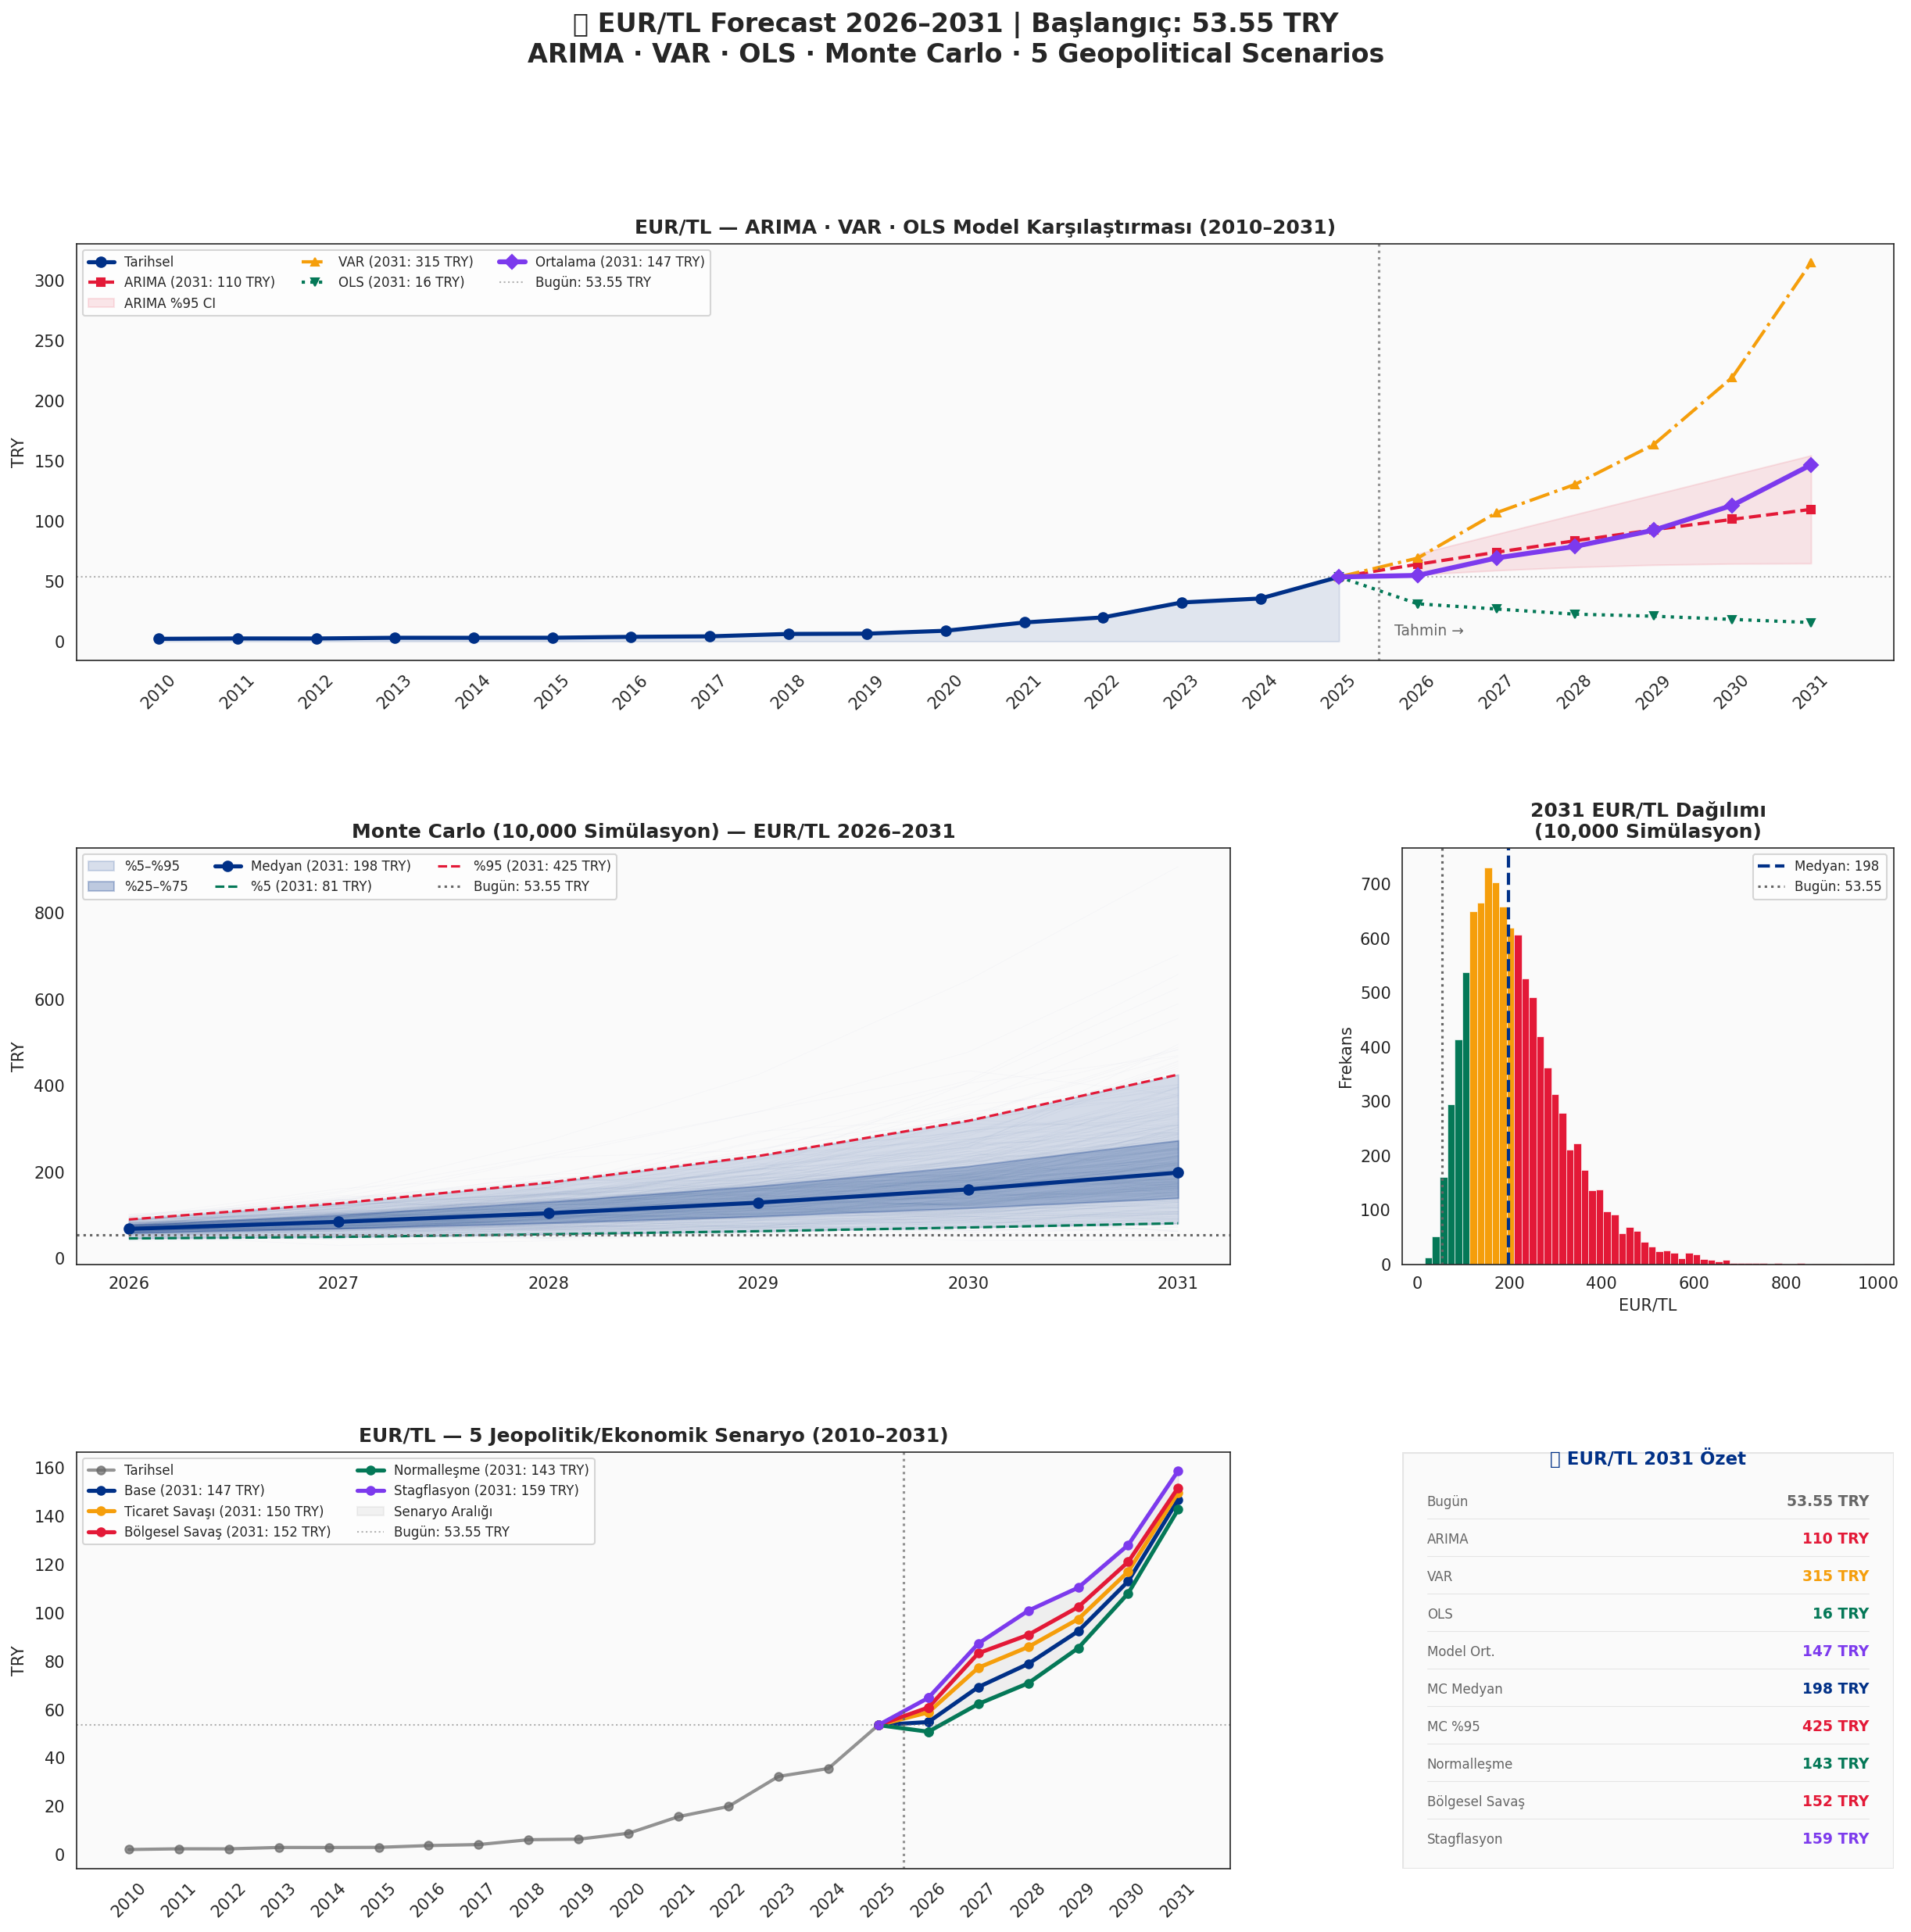

✅ Kapsamlı forecast grafiği kaydedildi!


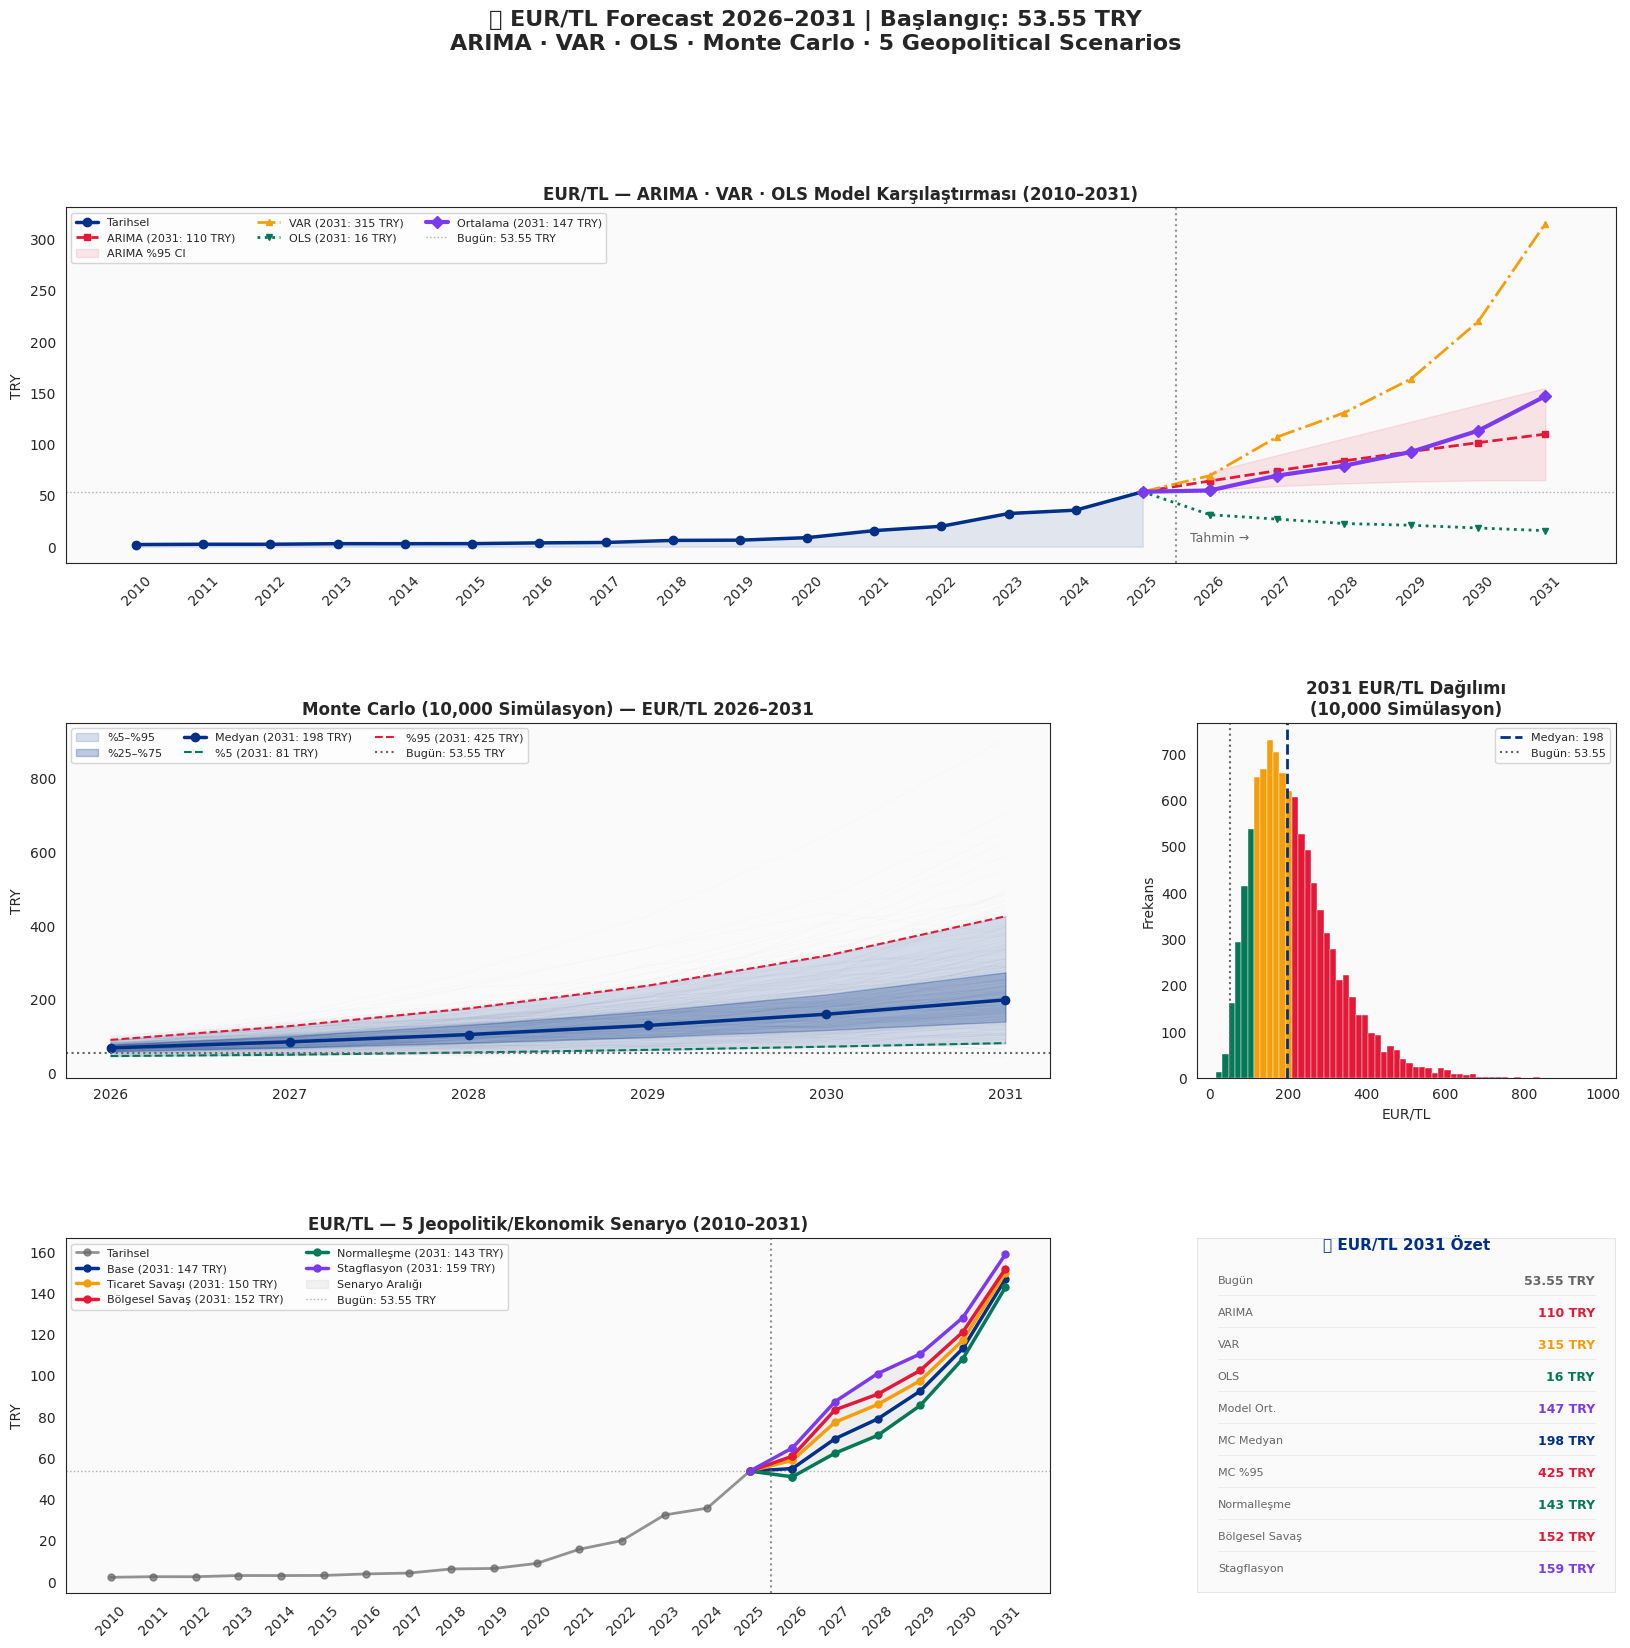

In [9]:
fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('💶 EUR/TL Forecast 2026–2031 | Başlangıç: 53.55 TRY\nARIMA · VAR · OLS · Monte Carlo · 5 Geopolitical Scenarios',
             fontsize=16, fontweight='bold', y=0.99)

hist_years = df['year'].values
connect = [hist_years[-1], forecast_years[0]]

# --- Grafik 1: 3 Model Karşılaştırması (geniş) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(hist_years, df['eur_tl'], color=BLUE, linewidth=2.5,
         marker='o', markersize=6, label='Tarihsel', zorder=5)
ax1.fill_between(hist_years, df['eur_tl'], alpha=0.1, color=BLUE)

ax1.plot(connect + list(forecast_years),
         [df['eur_tl'].iloc[-1], arima_forecast[0]] + list(arima_forecast),
         color=RED, linewidth=2, linestyle='--', marker='s',
         markersize=5, label=f'ARIMA (2031: {arima_forecast[-1]:.0f} TRY)')
ax1.fill_between(forecast_years, arima_conf[:,0], arima_conf[:,1],
                 alpha=0.1, color=RED, label='ARIMA %95 CI')

ax1.plot(connect + list(forecast_years),
         [df['eur_tl'].iloc[-1], var_eur_forecast[0]] + list(var_eur_forecast),
         color=ORANGE, linewidth=2, linestyle='-.', marker='^',
         markersize=5, label=f'VAR (2031: {var_eur_forecast[-1]:.0f} TRY)')

ax1.plot(connect + list(forecast_years),
         [df['eur_tl'].iloc[-1], ols_forecast.iloc[0]] + list(ols_forecast),
         color=GREEN, linewidth=2, linestyle=':', marker='v',
         markersize=5, label=f'OLS (2031: {ols_forecast.iloc[-1]:.0f} TRY)')

ax1.plot(connect + list(forecast_years),
         [df['eur_tl'].iloc[-1], model_avg[0]] + list(model_avg),
         color=PURPLE, linewidth=3, marker='D',
         markersize=6, label=f'Ortalama (2031: {model_avg[-1]:.0f} TRY)', zorder=6)

ax1.axvline(x=2025.5, color=GRAY, linewidth=1.5, linestyle=':', alpha=0.7)
ax1.text(2025.7, 5, 'Tahmin →', fontsize=9, color=GRAY)
ax1.axhline(y=53.55, color=GRAY, linewidth=1, linestyle=':',
            alpha=0.5, label='Bugün: 53.55 TRY')
ax1.set_title('EUR/TL — ARIMA · VAR · OLS Model Karşılaştırması (2010–2031)',
              fontweight='bold')
ax1.set_ylabel('TRY')
ax1.legend(loc='upper left', fontsize=8, ncol=3)
ax1.set_facecolor('#fafafa')
ax1.set_xticks(list(hist_years) + forecast_years)
ax1.tick_params(axis='x', rotation=45)

# --- Grafik 2: Monte Carlo ---
ax2 = fig.add_subplot(gs[1, :2])
for i in range(300):
    ax2.plot(forecast_years, mc_results.iloc[:, i],
             color=BLUE, alpha=0.02, linewidth=0.5)

p5  = [np.percentile(mc_results.loc[y], 5)  for y in forecast_years]
p25 = [np.percentile(mc_results.loc[y], 25) for y in forecast_years]
p50 = [np.percentile(mc_results.loc[y], 50) for y in forecast_years]
p75 = [np.percentile(mc_results.loc[y], 75) for y in forecast_years]
p95 = [np.percentile(mc_results.loc[y], 95) for y in forecast_years]

ax2.fill_between(forecast_years, p5, p95, alpha=0.15, color=BLUE, label='%5–%95')
ax2.fill_between(forecast_years, p25, p75, alpha=0.25, color=BLUE, label='%25–%75')
ax2.plot(forecast_years, p50, color=BLUE, linewidth=2.5,
         marker='o', markersize=6, label=f'Medyan (2031: {p50[-1]:.0f} TRY)')
ax2.plot(forecast_years, p5, color=GREEN, linewidth=1.5,
         linestyle='--', label=f'%5 (2031: {p5[-1]:.0f} TRY)')
ax2.plot(forecast_years, p95, color=RED, linewidth=1.5,
         linestyle='--', label=f'%95 (2031: {p95[-1]:.0f} TRY)')
ax2.axhline(y=53.55, color=GRAY, linewidth=1.5,
            linestyle=':', label='Bugün: 53.55 TRY')
ax2.set_title('Monte Carlo (10,000 Simülasyon) — EUR/TL 2026–2031',
              fontweight='bold')
ax2.set_ylabel('TRY')
ax2.legend(fontsize=8, ncol=3)
ax2.set_facecolor('#fafafa')

# --- Grafik 3: 2031 Dağılımı ---
ax3 = fig.add_subplot(gs[1, 2])
final_vals = mc_results.loc[2031]
n, bins, patches = ax3.hist(final_vals, bins=60,
                              edgecolor='white', linewidth=0.3)
for patch, left in zip(patches, bins[:-1]):
    if left < 100:
        patch.set_facecolor(GREEN)
    elif left < 200:
        patch.set_facecolor(ORANGE)
    else:
        patch.set_facecolor(RED)
ax3.axvline(x=np.median(final_vals), color=BLUE, linewidth=2,
            linestyle='--', label=f'Medyan: {np.median(final_vals):.0f}')
ax3.axvline(x=53.55, color=GRAY, linewidth=1.5,
            linestyle=':', label='Bugün: 53.55')
ax3.set_title('2031 EUR/TL Dağılımı\n(10,000 Simülasyon)', fontweight='bold')
ax3.set_xlabel('EUR/TL')
ax3.set_ylabel('Frekans')
ax3.legend(fontsize=8)
ax3.set_facecolor('#fafafa')

# --- Grafik 4: 5 Senaryo ---
ax4 = fig.add_subplot(gs[2, :2])
ax4.plot(hist_years, df['eur_tl'], color=GRAY, linewidth=2,
         marker='o', markersize=5, label='Tarihsel', alpha=0.7)

for s_name, s_data in scenarios.items():
    vals = scenario_results[s_name]
    ax4.plot(connect + list(forecast_years),
             [df['eur_tl'].iloc[-1], vals[0]] + vals,
             color=s_data['color'], linewidth=2.5, marker='o',
             markersize=5, label=f"{s_name} (2031: {vals[-1]:.0f} TRY)")

ax4.fill_between(forecast_years,
                 scenario_results['Normalleşme'],
                 scenario_results['Stagflasyon'],
                 alpha=0.08, color=GRAY, label='Senaryo Aralığı')
ax4.axvline(x=2025.5, color=GRAY, linewidth=1.5, linestyle=':', alpha=0.7)
ax4.axhline(y=53.55, color=GRAY, linewidth=1,
            linestyle=':', alpha=0.5, label='Bugün: 53.55 TRY')
ax4.set_title('EUR/TL — 5 Jeopolitik/Ekonomik Senaryo (2010–2031)',
              fontweight='bold')
ax4.set_ylabel('TRY')
ax4.legend(fontsize=8, ncol=2)
ax4.set_facecolor('#fafafa')
ax4.set_xticks(list(hist_years) + forecast_years)
ax4.tick_params(axis='x', rotation=45)

# --- Grafik 5: Özet KPI ---
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
ax5.set_facecolor('#fafafa')
ax5.add_patch(plt.Rectangle((0,0), 1, 1,
              transform=ax5.transAxes,
              facecolor='#fafafa', edgecolor='#e5e5e5', linewidth=1.5))

ax5.text(0.5, 0.97, '💶 EUR/TL 2031 Özet',
         transform=ax5.transAxes, fontsize=11,
         fontweight='bold', ha='center', color=BLUE)

kpis = [
    ('Bugün', '53.55 TRY', GRAY),
    ('ARIMA', f'{arima_forecast[-1]:.0f} TRY', RED),
    ('VAR', f'{var_eur_forecast[-1]:.0f} TRY', ORANGE),
    ('OLS', f'{ols_forecast.iloc[-1]:.0f} TRY', GREEN),
    ('Model Ort.', f'{model_avg[-1]:.0f} TRY', PURPLE),
    ('MC Medyan', f'{np.median(mc_results.loc[2031]):.0f} TRY', BLUE),
    ('MC %95', f'{np.percentile(mc_results.loc[2031],95):.0f} TRY', RED),
    ('Normalleşme', f'{scenario_results["Normalleşme"][-1]:.0f} TRY', GREEN),
    ('Bölgesel Savaş', f'{scenario_results["Bölgesel Savaş"][-1]:.0f} TRY', RED),
    ('Stagflasyon', f'{scenario_results["Stagflasyon"][-1]:.0f} TRY', PURPLE),
]

for i, (label, value, color) in enumerate(kpis):
    y = 0.88 - i * 0.09
    ax5.text(0.05, y, label, transform=ax5.transAxes,
             fontsize=8, color=GRAY, va='center')
    ax5.text(0.95, y, value, transform=ax5.transAxes,
             fontsize=9, fontweight='bold', color=color,
             ha='right', va='center')
    if i < len(kpis)-1:
        ax5.plot([0.05, 0.95], [y-0.04, y-0.04],
                 transform=ax5.transAxes,
                 color='#e5e5e5', linewidth=0.5)

plt.savefig('eur_tl_forecast.png', dpi=150, bbox_inches='tight')
from IPython.display import Image, display
display(Image('eur_tl_forecast.png'))
print("✅ Kapsamlı forecast grafiği kaydedildi!")

In [10]:
from google.colab import files
files.download('eur_tl_forecast.png')
print("✅ İndirildi!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ İndirildi!
